<a href="https://colab.research.google.com/github/oleg61/DataScient/blob/Learn_AI/%D0%94%D0%97_2_%D0%92%D0%BE%D1%80%D0%BE%D0%BF%D0%B0%D0%B5%D0%B2_%D0%9E%D0%A1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Dogs vs Cats

https://www.kaggle.com/c/dogs-vs-cats-redux-kernels-edition

In [1]:
# Подключаем Google Drive (если нужно сохранять веса/логи)
from google.colab import drive
drive.mount('/content/drive')

# Установим Kaggle CLI (если ещё не установлено)
!pip install -q kaggle

Mounted at /content/drive


# Аутентификация в Kaggle

In [5]:
import os
import json

# Создаём папку и загружаем kaggle.json
#os.makedirs('/content/.kaggle', exist_ok=True)

# Замените на путь к вашему kaggle.json в Google Drive, если храните там:
!cp "/content/drive/MyDrive/kaggle/kaggle.json" /content/drive/MyDrive/kaggle/
# ИЛИ просто загрузите вручную:

#from google.colab import files
#print("Загрузите файл kaggle.json (из аккаунта Kaggle → Account → API → Create New API Token)")
#uploaded = files.upload()  # Загружаем kaggle.json

with open('/content/drive/MyDrive/kaggle/kaggle.json', 'r') as f:
    kaggle_creds = json.load(f)
    print(f"API Token для пользователя: {kaggle_creds['username']}")

#!cp kaggle.json /content/drive/MyDrive/kaggle/
!chmod 600 /content/drive/MyDrive/kaggle/kaggle.json

cp: '/content/drive/MyDrive/kaggle/kaggle.json' and '/content/drive/MyDrive/kaggle/kaggle.json' are the same file
API Token для пользователя: olegsergeevich
cp: cannot stat 'kaggle.json': No such file or directory


In [6]:
import cv2
import numpy as np
import tensorflow as tf
from tensorflow.keras.applications import vgg16

print(tf.__version__)
print(tf.executing_eagerly())

2.19.0
True


# Распакуем датасет

In [7]:
# Скачиваем датасет (dogs-vs-cats-redux-kernels-edition)
#!kaggle competitions download -c dogs-vs-cats-redux-kernels-edition

# Распаковка
#!unzip -q dogs-vs-cats-redux-kernels-edition.zip -d data
!unzip -q /content/drive/MyDrive/kaggle/test.zip -d /content/drive/MyDrive/kaggle/
!unzip -q /content/drive/MyDrive/kaggle/train.zip -d /content/drive/MyDrive/kaggle/

## Подготовим структуру данных для ImageDataGenerator

In [ ]:
import os
import shutil
from tqdm import tqdm

# Создаём структуру: train/cats/, train/dogs/, val/cats/, val/dogs/
base_dir = '/content/drive/MyDrive/kaggle'
train_dir = os.path.join(base_dir, 'train')
val_dir = os.path.join(base_dir, 'val')
os.makedirs(os.path.join(val_dir, 'cats'), exist_ok=True)
os.makedirs(os.path.join(val_dir, 'dogs'), exist_ok=True)

# Перемещаем 10% из train → val для валидации
import random
fnames = [f for f in os.listdir(train_dir) if f.endswith('.jpg')]
random.seed(42)
random.shuffle(fnames)

val_size = int(0.1 * len(fnames))
val_fnames = fnames[:val_size]
train_fnames = fnames[val_size:]

print(f"Train: {len(train_fnames)}, Val: {len(val_fnames)}")

for fname in tqdm(val_fnames, desc="Moving to val/"):
    label = 'cats' if 'cat' in fname else 'dogs'
    src = os.path.join(train_dir, fname)
    dst = os.path.join(val_dir, label, fname)
    shutil.move(src, dst)

Train: 22500, Val: 2500


Moving to val/: 100%|██████████| 2500/2500 [00:00<00:00, 32851.57it/s]


## Загрузчики данных + Augmentation

In [8]:
import os
import shutil
from tqdm import tqdm

base_dir = '/content/drive/MyDrive/kaggle'
raw_train_dir = os.path.join(base_dir, 'train')  # сюда распаковались train/*.jpg
test_dir = os.path.join(base_dir, 'test')        # test/*.jpg

# Создаём структуру:
# data/
# ├── train/      → будет переименовано в raw_train, а ниже создадим train/cats|dogs
# ├── val/
# │   ├── cats/
# │   └── dogs/
# └── train_prepared/
#     ├── cats/
#     └── dogs/

# 1. Переименуем исходную train → raw_train
if not os.path.exists(os.path.join(base_dir, 'raw_train')):
    os.rename(raw_train_dir, os.path.join(base_dir, 'raw_train'))
raw_train_dir = os.path.join(base_dir, 'raw_train')

# 2. Создаём директории
train_cats_dir = os.path.join(base_dir, 'train_prepared', 'cats')
train_dogs_dir = os.path.join(base_dir, 'train_prepared', 'dogs')
val_cats_dir = os.path.join(base_dir, 'val', 'cats')
val_dogs_dir = os.path.join(base_dir, 'val', 'dogs')

os.makedirs(train_cats_dir, exist_ok=True)
os.makedirs(train_dogs_dir, exist_ok=True)
os.makedirs(val_cats_dir, exist_ok=True)
os.makedirs(val_dogs_dir, exist_ok=True)

# 3. Собираем имена файлов
fnames = [f for f in os.listdir(raw_train_dir) if f.endswith('.jpg')]
print(f"Всего обучающих изображений: {len(fnames)}")

# 4. Разделяем: 90% → train, 10% → val
import random
random.seed(42)
random.shuffle(fnames)

val_split = int(0.1 * len(fnames))
val_fnames = fnames[:val_split]
train_fnames = fnames[val_split:]

print(f"→ Train: {len(train_fnames)}, Val: {len(val_fnames)}")

# 5. Копируем файлы в правильные папки
def copy_files(filenames, src_dir, cats_dir, dogs_dir):
    for fname in tqdm(filenames, desc="Copying"):
        src_path = os.path.join(src_dir, fname)
        if 'cat' in fname.lower():
            dst_path = os.path.join(cats_dir, fname)
        else:
            dst_path = os.path.join(dogs_dir, fname)
        shutil.copy(src_path, dst_path)

print("Copying train files...")
copy_files(train_fnames, raw_train_dir, train_cats_dir, train_dogs_dir)
print("Copying val files...")
copy_files(val_fnames, raw_train_dir, val_cats_dir, val_dogs_dir)

Всего обучающих изображений: 25000
→ Train: 22500, Val: 2500
Copying train files...


Copying: 100%|██████████| 22500/22500 [07:52<00:00, 47.64it/s]


Copying val files...


Copying: 100%|██████████| 2500/2500 [00:26<00:00, 95.59it/s]


In [10]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Аугментация для train
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

# Только rescale для val & test
val_datagen = ImageDataGenerator(rescale=1./255)
test_datagen = ImageDataGenerator(rescale=1./255)

batch_size = 32

train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(224, 224),
    batch_size=batch_size,
    class_mode='binary'  # cats=0, dogs=1
)

val_generator = val_datagen.flow_from_directory(
    val_dir,
    target_size=(224, 224),
    batch_size=batch_size,
    class_mode='binary'
)

# Для теста — без labels (нужны только предсказания)
test_dir = os.path.join(base_dir, 'test')
test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=(224, 224),
    batch_size=1,
    class_mode=None,  # без меток
    shuffle=False  # важно — порядок файлов = порядку в submission!
)

Found 22500 images belonging to 2 classes.
Found 2500 images belonging to 2 classes.
Found 0 images belonging to 0 classes.


In [11]:
train_dir = os.path.join(base_dir, 'train_prepared')  # ← ВАЖНО!
val_dir = os.path.join(base_dir, 'val')

train_generator = train_datagen.flow_from_directory(
    train_dir,           # теперь содержит cats/ и dogs/
    target_size=(224, 224),
    batch_size=batch_size,
    class_mode='binary'
)

val_generator = val_datagen.flow_from_directory(
    val_dir,             # тоже содержит cats/ и dogs/
    target_size=(224, 224),
    batch_size=batch_size,
    class_mode='binary'
)

Found 22500 images belonging to 2 classes.
Found 2500 images belonging to 2 classes.


In [12]:
import numpy as np
test_filenames = sorted(os.listdir(test_dir))
print("Первые 5 имён тестовых файлов:", test_filenames[:5])
# Должны быть: ['1.jpg', '10.jpg', '100.jpg', ...] — как в sample_submission.csv
# Если нет — используем `test_generator.filenames = sorted(test_generator.filenames)`

Первые 5 имён тестовых файлов: ['1.jpg', '10.jpg', '100.jpg', '1000.jpg', '10000.jpg']


## Загрузка и Fine-tuning MobileNetV2

In [13]:
import tensorflow as tf
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam

# Загружаем MobileNetV2 без головы
base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

# Замораживаем базовую модель (можно разморозить позже)
base_model.trainable = False

# Добавляем кастомную голову
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation='relu')(x)
x = tf.keras.layers.Dropout(0.5)(x)
predictions = Dense(1, activation='sigmoid')(x)  # binary classification

model = Model(inputs=base_model.input, outputs=predictions)

# Компиляция
model.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 112, 112,  │        864 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 112, 112,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 112, 112,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 112, 112,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 112, 112,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 113, 113,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 56, 56,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 56, 56,    │      2,304 │ block_1_depthwis

 Total params: 2,422,081 (9.24 MB)

 Trainable params: 164,097 (641.00 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

## Обучение (с колбэками)

In [19]:
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau

callbacks = [
    ModelCheckpoint('/content/drive/MyDrive/kaggle/cats_vs_dogs_best.h5',
                    monitor='val_loss', save_best_only=True, verbose=1),
    EarlyStopping(patience=5, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-7)
]

history = model.fit(
    train_generator,
    steps_per_epoch=len(train_fnames) // batch_size,
    epochs=15,
    validation_data=val_generator,
    validation_steps=len(val_fnames) // batch_size,
    callbacks=callbacks
)

Epoch 1/15
703/703 ━━━━━━━━━━━━━━━━━━━━ 0s 536ms/step - accuracy: 0.9618 - loss: 0.0963

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()



Epoch 1: val_loss improved from inf to 0.05858, saving model to /content/drive/MyDrive/kaggle/cats_vs_dogs_best.h5


703/703 ━━━━━━━━━━━━━━━━━━━━ 394s 560ms/step - accuracy: 0.9618 - loss: 0.0963 - val_accuracy: 0.9776 - val_loss: 0.0586 - learning_rate: 0.0010
Epoch 2/15
  1/703 ━━━━━━━━━━━━━━━━━━━━ 25s 37ms/step - accuracy: 0.9688 - loss: 0.1278

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()



Epoch 2: val_loss improved from 0.05858 to 0.05261, saving model to /content/drive/MyDrive/kaggle/cats_vs_dogs_best.h5


703/703 ━━━━━━━━━━━━━━━━━━━━ 13s 18ms/step - accuracy: 0.9688 - loss: 0.1278 - val_accuracy: 0.9796 - val_loss: 0.0526 - learning_rate: 0.0010
Epoch 3/15
703/703 ━━━━━━━━━━━━━━━━━━━━ 0s 507ms/step - accuracy: 0.9691 - loss: 0.0756
Epoch 3: val_loss improved from 0.05261 to 0.04107, saving model to /content/drive/MyDrive/kaggle/cats_vs_dogs_best.h5


703/703 ━━━━━━━━━━━━━━━━━━━━ 369s 524ms/step - accuracy: 0.9691 - loss: 0.0756 - val_accuracy: 0.9844 - val_loss: 0.0411 - learning_rate: 0.0010
Epoch 4/15
  1/703 ━━━━━━━━━━━━━━━━━━━━ 25s 36ms/step - accuracy: 1.0000 - loss: 0.0153
Epoch 4: val_loss did not improve from 0.04107
703/703 ━━━━━━━━━━━━━━━━━━━━ 11s 16ms/step - accuracy: 1.0000 - loss: 0.0153 - val_accuracy: 0.9840 - val_loss: 0.0414 - learning_rate: 0.0010
Epoch 5/15
703/703 ━━━━━━━━━━━━━━━━━━━━ 0s 509ms/step - accuracy: 0.9699 - loss: 0.0739
Epoch 5: val_loss did not improve from 0.04107
703/703 ━━━━━━━━━━━━━━━━━━━━ 370s 526ms/step - accuracy: 0.9699 - loss: 0.0739 - val_accuracy: 0.9816 - val_loss: 0.0474 - learning_rate: 0.0010
Epoch 6/15
  1/703 ━━━━━━━━━━━━━━━━━━━━ 26s 37ms/step - accuracy: 0.9688 - loss: 0.0312
Epoch 6: val_loss did not improve from 0.04107
703/703 ━━━━━━━━━━━━━━━━━━━━ 12s 17ms/step - accuracy: 0.9688 - loss: 0.0312 - val_accuracy: 0.9816 - val_loss: 0.0471 - learning_rate: 0.0010
Epoch 7/15
703/703 

# Визуализация

In [28]:
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 112, 112,  │        864 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 112, 112,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 112, 112,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 112, 112,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 112, 112,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 113, 113,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 56, 56,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 56, 56,    │      2,304 │ block_1_depthwis

 Total params: 2,422,081 (9.24 MB)

 Trainable params: 164,097 (641.00 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

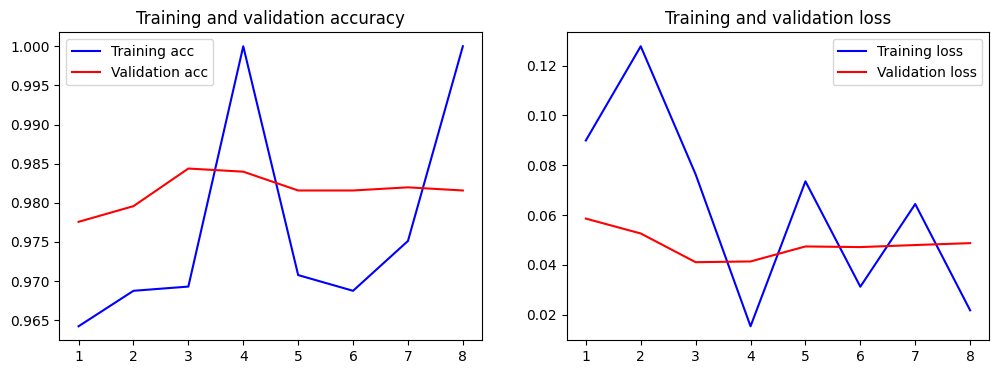

In [23]:
import matplotlib.pyplot as plt

acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

epochs = range(1, len(acc) + 1)

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(epochs, acc, 'b', label='Training acc')
plt.plot(epochs, val_acc, 'r', label='Validation acc')
plt.title('Training and validation accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(epochs, loss, 'b', label='Training loss')
plt.plot(epochs, val_loss, 'r', label='Validation loss')
plt.title('Training and validation loss')
plt.legend()
plt.show()

In [42]:
print("🔍 Test generator info:")
print(f"  Directory: {test_generator.directory}")
print(f"  Num images: {test_generator.samples}")
print(f"  Batch size: {test_generator.batch_size}")
print(f"  Class mode: {test_generator.class_mode}")
if hasattr(test_generator, 'filenames'):
    print(f"  First 3 filenames: {test_generator.filenames[:3]}")

assert test_generator.samples > 0, "❌ test_generator пустой! Проверьте структуру папки."

🔍 Test generator info:
  Directory: /content/drive/MyDrive/kaggle/test
  Num images: 12500
  Batch size: 32
  Class mode: None
  First 3 filenames: ['1.jpg', '10.jpg', '100.jpg']


# Предсказание и формирование submission.csv

In [37]:
test_files = [f for f in os.listdir(test_dir) if f.endswith('.jpg')]
print("Пример имён файлов:", test_files[:10])

Пример имён файлов: ['1.jpg', '10.jpg', '100.jpg', '1000.jpg', '10000.jpg', '10001.jpg', '10002.jpg', '10003.jpg', '10004.jpg', '10005.jpg']


In [38]:
import pandas as pd

# Собираем все тестовые файлы
test_files = [f for f in os.listdir(test_dir) if f.endswith('.jpg')]
test_df = pd.DataFrame({
    'filename': test_files
})

# Генератор из DataFrame
test_generator = test_datagen.flow_from_dataframe(
    dataframe=test_df,
    directory=test_dir,          # здесь лежат файлы
    x_col='filename',
    y_col=None,
    target_size=(224, 224),
    batch_size=32,
    class_mode=None,
    shuffle=False
)

# ID из имён — сортируем так же, как в датафрейме (он уже в порядке файлов)
test_ids = [int(f.split('.')[0]) for f in test_df['filename']]

# Предсказание
preds = model.predict(test_generator, steps=len(test_df) // 32 + 1, verbose=1)

# Обрезаем лишнее (если batch > 1 и steps округлились вверх)
preds = preds[:len(test_df)]

Found 12500 validated image filenames.


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


391/391 ━━━━━━━━━━━━━━━━━━━━ 169s 419ms/step


In [39]:
# Сбрасываем генератор, чтобы начать с начала (важно!)
test_generator.reset()

# Предсказываем
preds = model.predict(test_generator, steps=len(test_filenames), verbose=1)
# preds.shape = (12500, 1) → одномерные вероятности "dog"

# Извлекаем ID из имён файлов: '123.jpg' → 123
test_ids = [int(fname.split('.')[0]) for fname in test_filenames]

# Формируем DataFrame в порядке submission (по возрастанию ID!)
import pandas as pd
submission = pd.DataFrame({
    'id': test_ids,
    'label': preds.flatten()
})

submission = submission.sort_values('id').reset_index(drop=True)

# Сохраняем
submission_path = '/content/drive/MyDrive/kaggle/submission.csv'
submission.to_csv(submission_path, index=False)
print("Файл сохранён:", submission_path)
print(submission.head())

# Скачиваем
from google.colab import files
files.download(submission_path)

12500/12500 ━━━━━━━━━━━━━━━━━━━━ 56s 4ms/step    


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


Файл сохранён: /content/drive/MyDrive/kaggle/submission.csv
   id     label
0   1  0.999306
1   2  0.999882
2   3  1.000000
3   4  0.999947
4   5  0.000042


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# LogLoss = 0.07854